In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

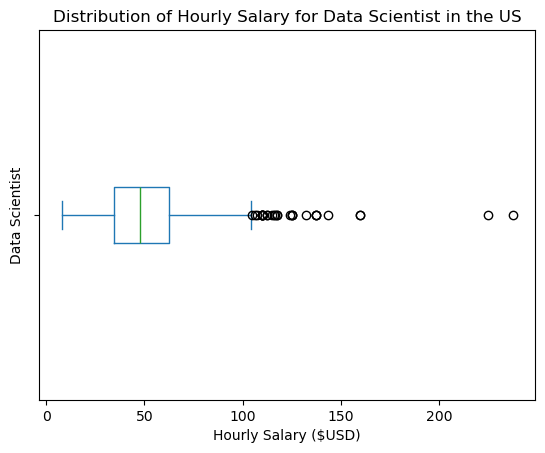

In [ ]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_US = df_DS_US.dropna(subset=['salary_hour_avg'])
df_DS_US['salary_hour_avg'].plot(kind='box', vert=False)
plt.ylabel('Data Scientist')
plt.xlabel('Hourly Salary ($USD)')
plt.gca().set_yticklabels('')
plt.title('Distribution of Hourly Salary for Data Scientist in the US')
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_28160\1673789602.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(country_list, labels=countries, vert=False)


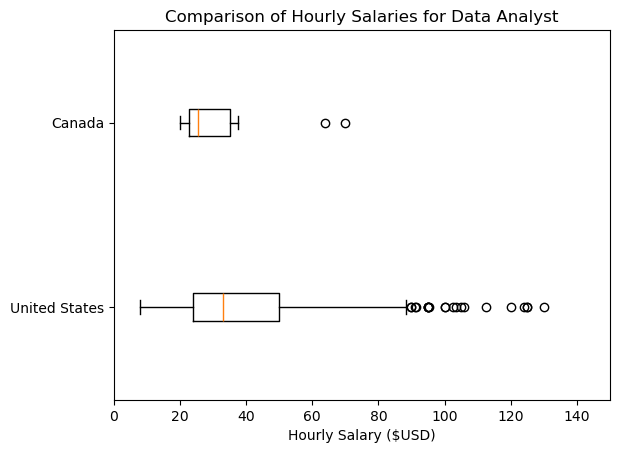

In [15]:
countries = ['United States', 'Canada']

df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(countries))].copy()
df_DA = df_DA.dropna(subset=['salary_hour_avg'])

country_list = [df_DA[df_DA['job_country'] == country]['salary_hour_avg'] for country in countries]
plt.boxplot(country_list, labels=countries, vert=False)
plt.xlim(0, 150)
plt.xlabel('Hourly Salary ($USD)')
plt.title('Comparison of Hourly Salaries for Data Analyst')
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14540\2083580728.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


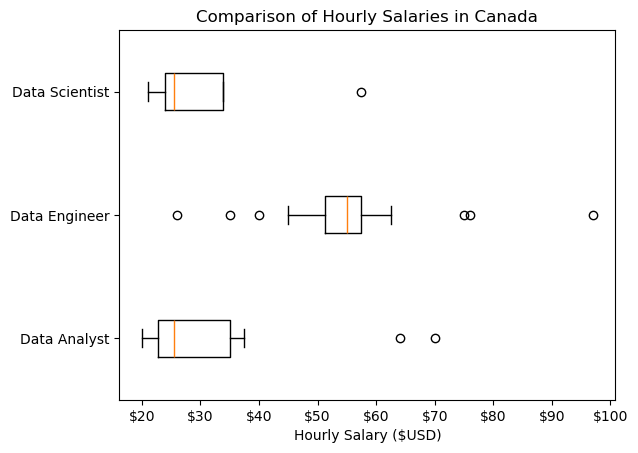

In [5]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_canada = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'Canada')].copy().dropna(subset=['salary_hour_avg'])
job_list = [df_canada[df_canada['job_title_short']==title]['salary_hour_avg'] for title in job_titles]
plt.boxplot(job_list, labels=job_titles, vert=False)
plt.xlabel('Hourly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:.0f}'))
plt.title('Comparison of Hourly Salaries in Canada')
plt.show()

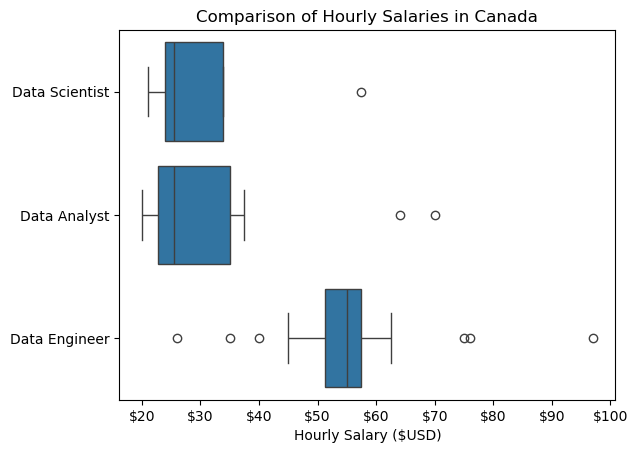

In [ ]:
import seaborn as sns

sns.boxplot(data=df_canada, x='salary_hour_avg', y='job_title_short')
# plt.boxplot(job_list, labels=job_titles, vert=False)
plt.xlabel('Hourly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:.0f}'))
plt.title('Comparison of Hourly Salaries in Canada')
plt.show()